In [1]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Set plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv("Superstore.csv.csv")

# Display first 5 rows
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [5]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (9994, 13)


In [6]:
# Display all column names
df.columns.tolist()

['Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Category',
 'Sub-Category',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [7]:
# Statistical summary
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Check missing values
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [9]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 17


In [10]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicate Rows after removal:", df.duplicated().sum())

Duplicate Rows after removal: 0


In [11]:
# Display data types
df.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

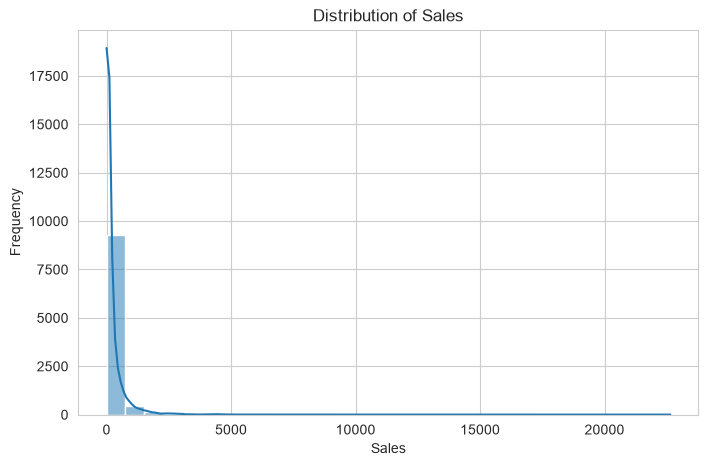

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

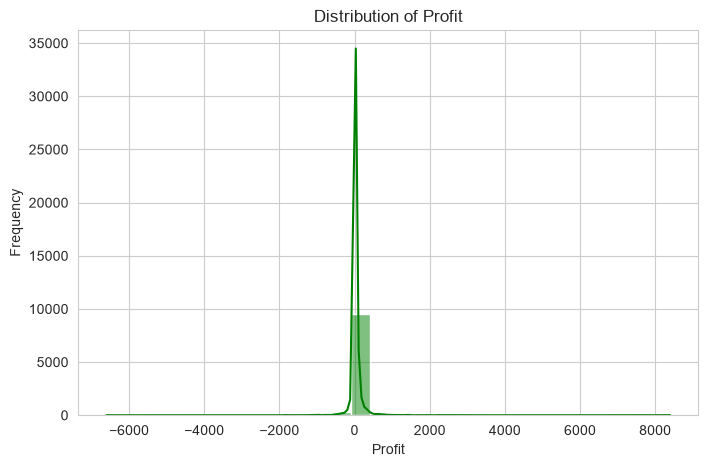

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=30, kde=True, color='green')

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

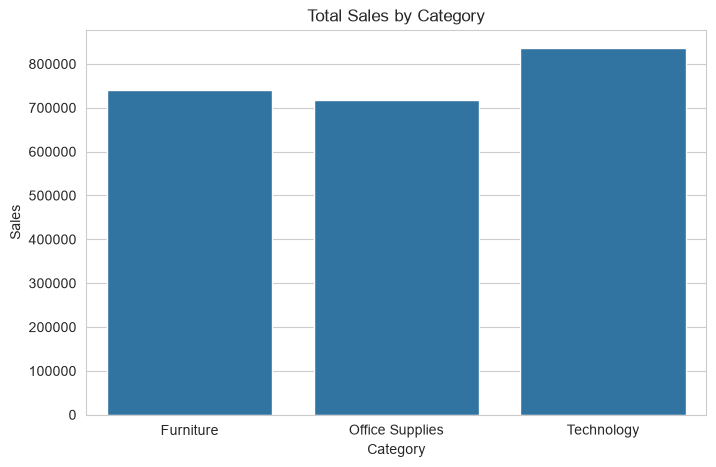

In [16]:
plt.figure(figsize=(8,5))

sales_category = df.groupby('Category')['Sales'].sum().reset_index()

sns.barplot(data=sales_category, x='Category', y='Sales')

plt.title("Total Sales by Category")
plt.show()

### Insight

Technology generated the highest sales among all product categories, indicating strong customer demand. Furniture and Office Supplies contributed less comparatively, suggesting opportunities for targeted marketing or product optimization.

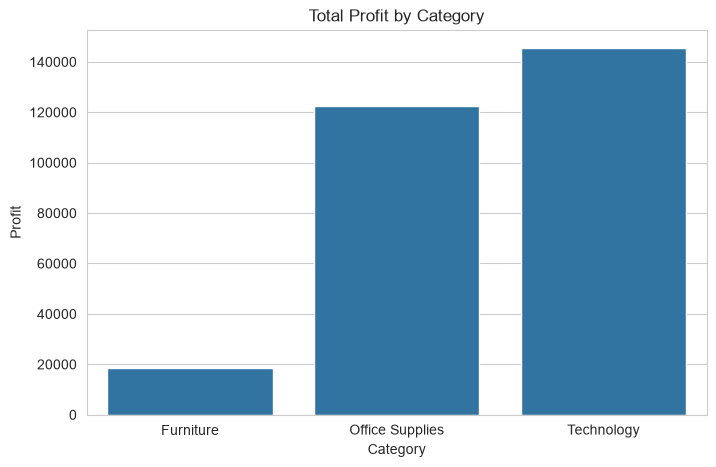

In [17]:
plt.figure(figsize=(8,5))

profit_category = df.groupby('Category')['Profit'].sum().reset_index()

sns.barplot(data=profit_category, x='Category', y='Profit')

plt.title("Total Profit by Category")
plt.show()

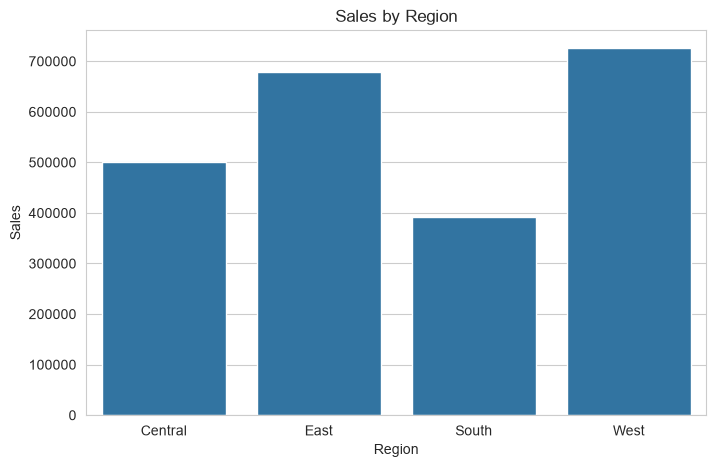

In [18]:
plt.figure(figsize=(8,5))

sales_region = df.groupby('Region')['Sales'].sum().reset_index()

sns.barplot(data=sales_region, x='Region', y='Sales')

plt.title("Sales by Region")
plt.show()

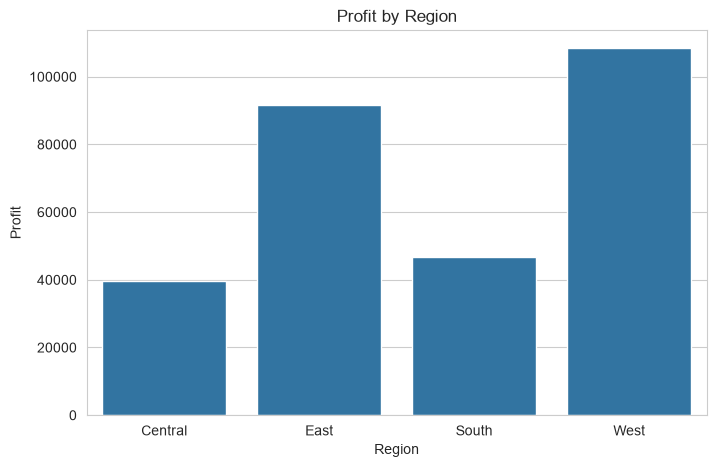

In [19]:
plt.figure(figsize=(8,5))

profit_region = df.groupby('Region')['Profit'].sum().reset_index()

sns.barplot(data=profit_region, x='Region', y='Profit')

plt.title("Profit by Region")
plt.show()

### Insight

The West region generated the highest overall profit, while other regions showed comparatively lower profitability. This may indicate stronger market performance or more effective sales strategies in the West.

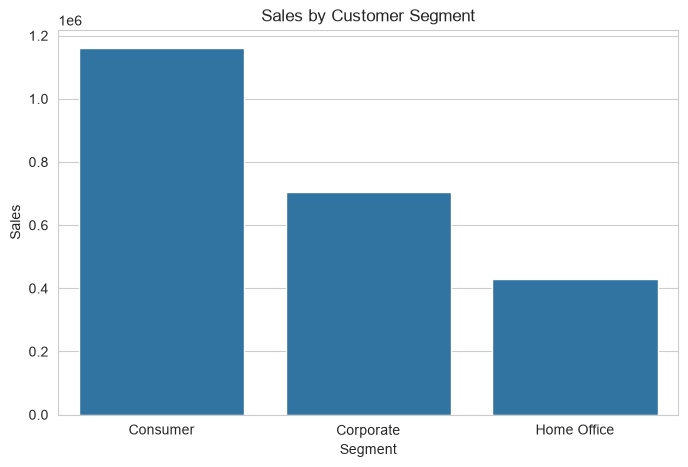

In [20]:
plt.figure(figsize=(8,5))

segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()

sns.barplot(data=segment_sales, x='Segment', y='Sales')

plt.title("Sales by Customer Segment")
plt.show()

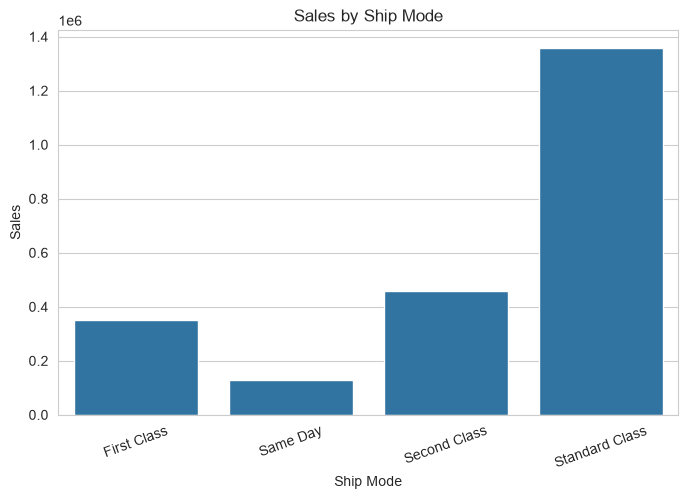

In [21]:
plt.figure(figsize=(8,5))

ship_sales = df.groupby('Ship Mode')['Sales'].sum().reset_index()

sns.barplot(data=ship_sales, x='Ship Mode', y='Sales')

plt.xticks(rotation=20)

plt.title("Sales by Ship Mode")

plt.show()

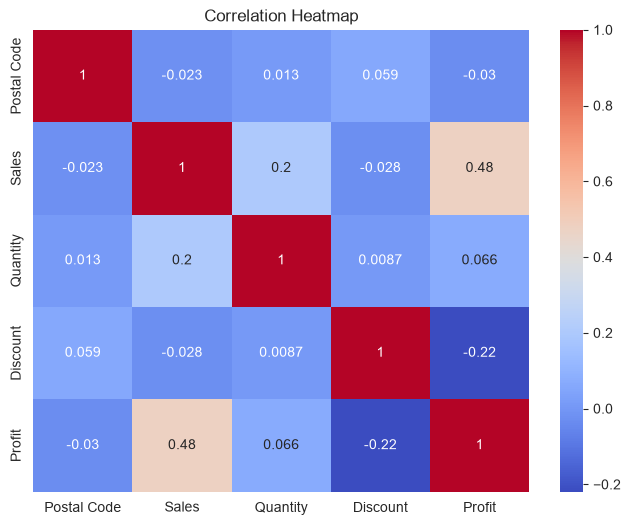

In [22]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Insight

Sales and Profit show a positive relationship, whereas Discount has a negative correlation with Profit. This reinforces the importance of balancing promotional discounts with profitability goals.

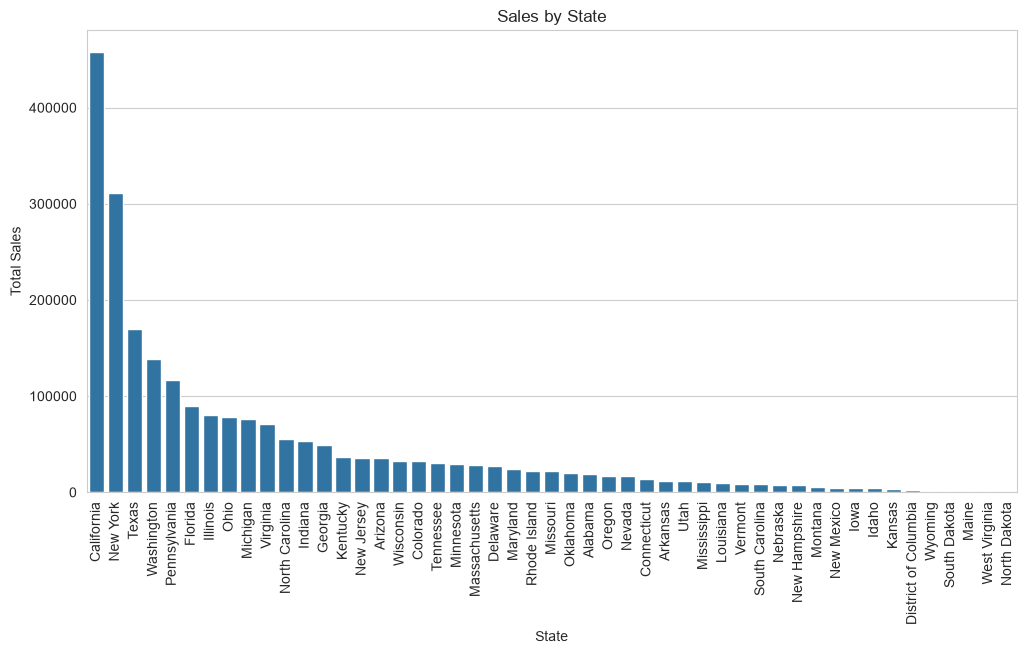

In [23]:
plt.figure(figsize=(12,6))

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

sns.barplot(x=state_sales.index, y=state_sales.values)

plt.xticks(rotation=90)
plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.show()

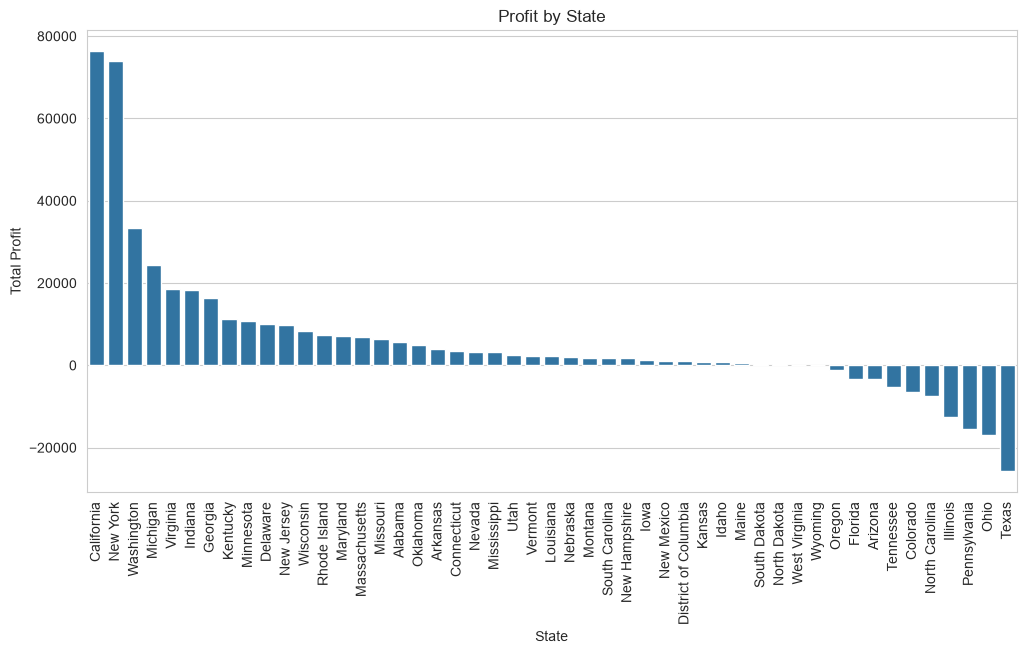

In [24]:
plt.figure(figsize=(12,6))

state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

sns.barplot(x=state_profit.index, y=state_profit.values)

plt.xticks(rotation=90)
plt.title("Profit by State")
plt.xlabel("State")
plt.ylabel("Total Profit")

plt.show()

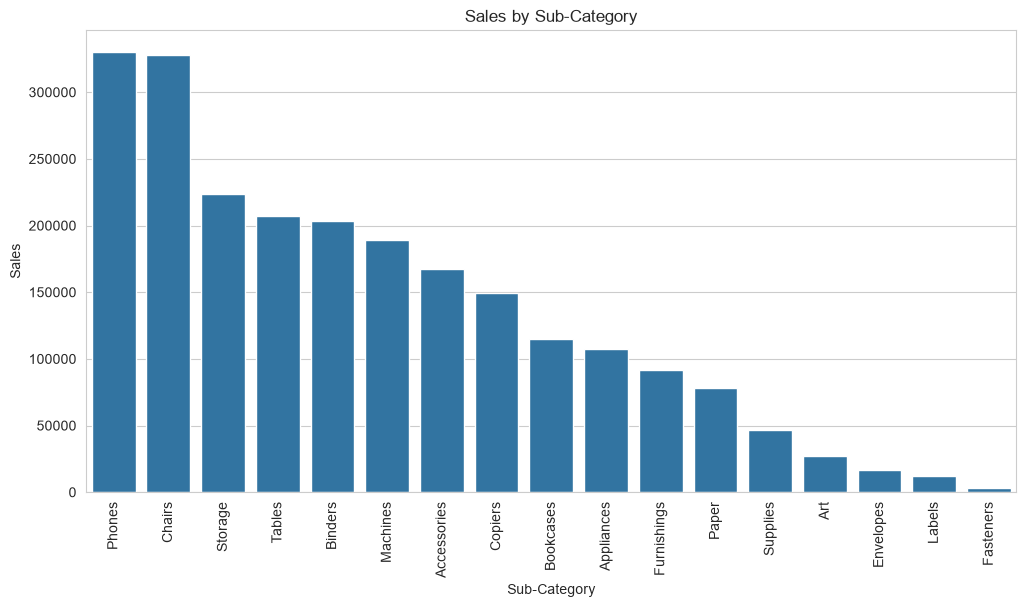

In [25]:
plt.figure(figsize=(12,6))

subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

sns.barplot(
    x=subcategory_sales.index,
    y=subcategory_sales.values
)

plt.xticks(rotation=90)
plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.show()

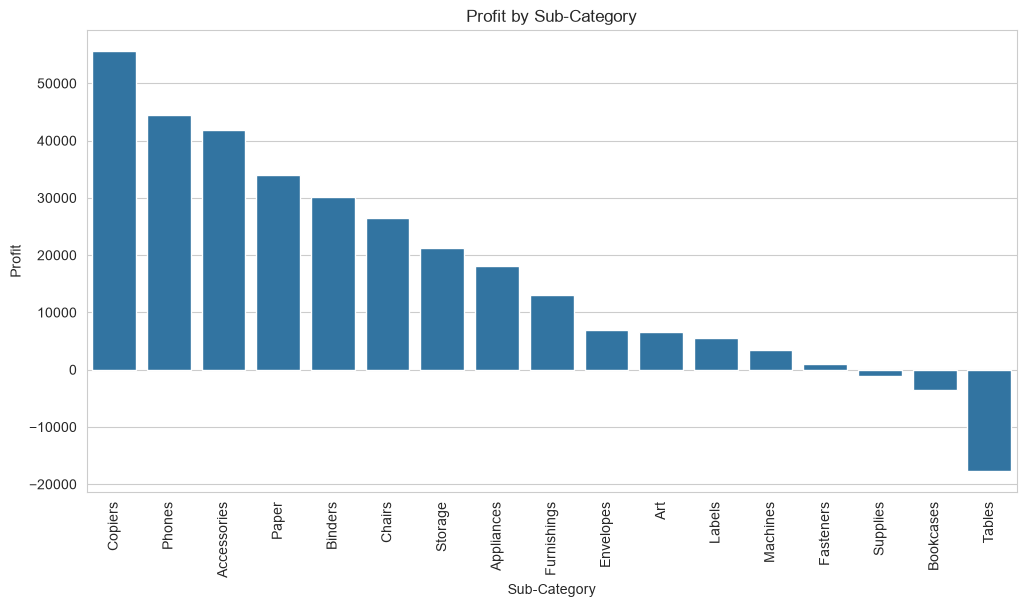

In [26]:
plt.figure(figsize=(12,6))

subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

sns.barplot(
    x=subcategory_profit.index,
    y=subcategory_profit.values
)

plt.xticks(rotation=90)
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.show()

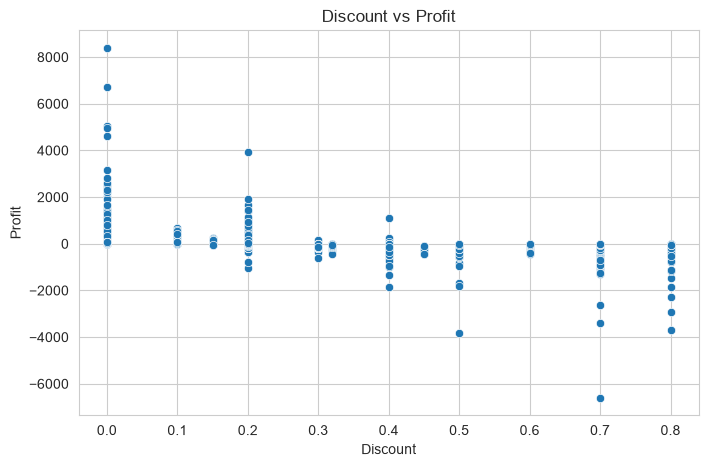

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

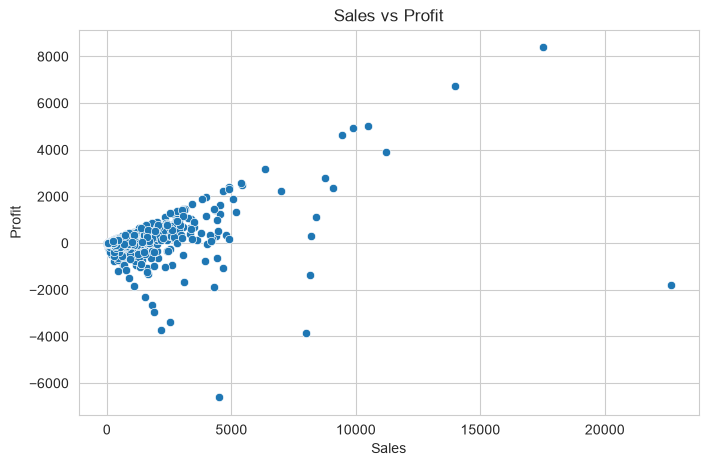

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit'
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

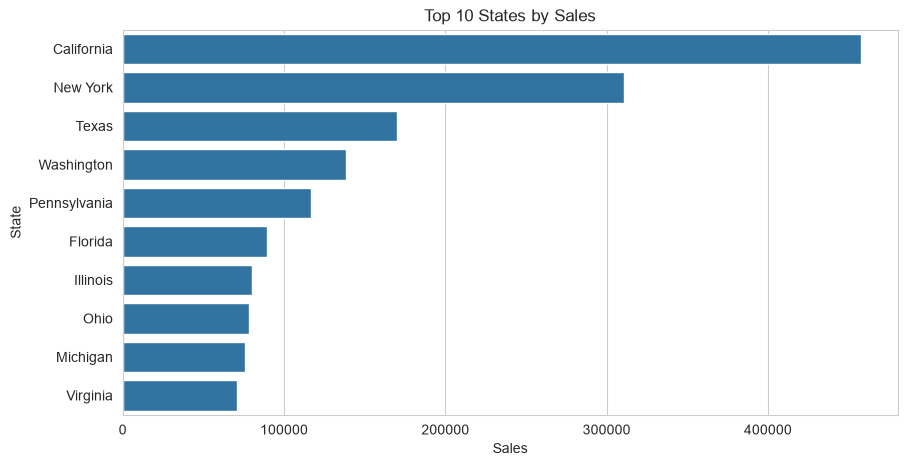

In [29]:
top10 = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.show()

# Business Insights

- Technology products generated the highest overall sales.
- Some states contribute significantly more sales than others.
- Higher discounts are often associated with lower profits.
- Customer segments differ in total sales contribution.
- Certain sub-categories generate high sales but relatively low profit, suggesting opportunities to optimize pricing or costs.

# Conclusion

This exploratory data analysis examined sales, profit, categories, regions, customer segments, and state-level performance.

Key findings include:
- Sales are unevenly distributed across categories and regions.
- Discounts can negatively impact profitability.
- High-performing states and product sub-categories were identified.
- The insights from this analysis can support better business decisions related to sales strategy, inventory planning, and profitability improvement.

The dataset is now well understood and can be used for dashboard creation and advanced analytics.